In [1]:
import importlib.util
print(importlib.util.find_spec("src"))


ModuleSpec(name='src', loader=<_frozen_importlib_external.SourceFileLoader object at 0x111529ee0>, origin='/Users/enzocanonero/Documents/PhD/tesi-codice/applied-asymtotics-dm/counting-exp/v0.2/src/__init__.py', submodule_search_locations=['/Users/enzocanonero/Documents/PhD/tesi-codice/applied-asymtotics-dm/counting-exp/v0.2/src'])


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.on import pvals_on, r_stat, r_star, expected_significance_on
from src.on_off import pvals_onoff, asimov_Zs_onoff, expected_significance_onoff

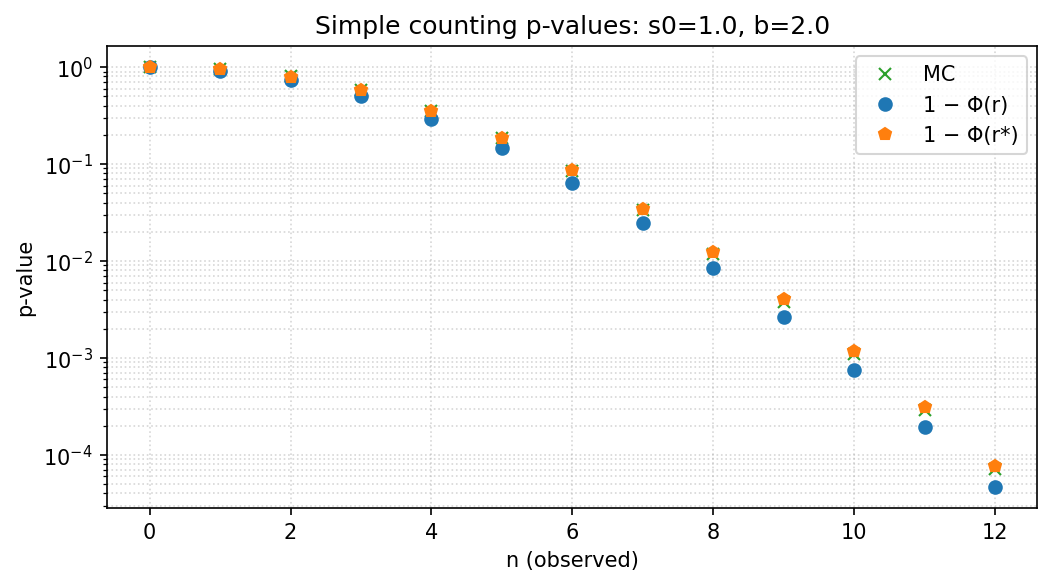

In [3]:
# Simple counting: single p-value plot
s0 = 1.0
b = 2.0

mu0 = s0 + b
n_vals = np.arange(0, int(np.ceil(mu0 + 5.0 * np.sqrt(mu0))) + 1, dtype=int)
out = pvals_on(s0, b, n_vals)
p_true = out['p_true']
p_r = out['p_r']
p_rstar = out['p_rstar']

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(n_vals, p_true,  marker="x", linestyle="None", label="MC", color="tab:green")
ax.plot(n_vals, p_r,     marker="o", linestyle="None", label="1 − Φ(r)", color="tab:blue")
ax.plot(n_vals, p_rstar, marker="p", linestyle="None", label="1 − Φ(r*)", color="tab:orange")
ax.set_yscale("log")
ax.set_xlabel("n (observed)")
ax.set_ylabel("p-value")
ax.set_title(f"Simple counting p-values: s0={s0}, b={b}")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.on import pvals_on, r_stat, r_star, expected_significance_on
from src.on_off import pvals_onoff, asimov_Zs_onoff, expected_significance_onoff
# Simple counting: Asimov vs median-expected Z (MC median)
s_true = 2.0
b_values = np.logspace(-1, 2, 80)

r_list = np.vectorize(lambda bb: r_stat_on(0.0, bb, s_true + bb))(b_values)
rstar_list = np.vectorize(lambda bb: r_star_on(0.0, bb, s_true + bb))(b_values)
zmed = expected_significance_on(s_true, b_values, n_outer=200, seed=12345)["Z_mc_median"]

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(b_values, r_list, label="Asimov r")
ax.plot(b_values, rstar_list, linestyle="--", label="Asimov r*")
ax.plot(b_values, zmed, linestyle="None", marker="x", label="MC median Z")
ax.set_xscale("log")
ax.set_xlabel("b")
ax.set_ylabel("Z")
ax.set_ylim(bottom=-1, top=max(r_list)+2.0)
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()
ax.set_title(f"Simple counting medsig: s_true={s_true}")
plt.show()

# On/off: Asimov vs MC median Z at one point (fast settings)
s_true = 2.0
b = 2.0
tau = 1.0

asim = asimov_Zs_onoff(s_true, b, tau)
mc = expected_significance_onoff(
    s_true, b, tau,
    n_outer=50,
    sigrel=0.01,
    min_toys=1000,
    max_toys=50000,
    seed=1234,
)

Z_mc = mc["Z_mc"]
fig, ax = plt.subplots(figsize=(7,4), dpi=150)
ax.hist(Z_mc, bins=30, density=True, alpha=0.4, label="MC Z distribution")
ax.axvline(mc["Z_mc_median"], color="tab:green", label="MC median Z")
ax.axvline(asim["Z_A_r"], color="tab:blue", linestyle="--", label="Asimov r")
ax.axvline(asim["Z_A_rstar"], color="tab:orange", linestyle=":", label="Asimov r*")
ax.set_xlabel("Z")
ax.set_ylabel("Density")
ax.set_title(f"on/off medsig at s_true={s_true}, b={b}, tau={tau}")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# On/off: single p-value plot
s0 = 1.0
b = 2.0
tau = 1.0

mu_s = s0 + b
mu_b = tau * b

m0_candidates = np.array([max(0, int(np.floor(mu_b + delta*np.sqrt(mu_b)))) for delta in (-1, 0, 1)])
m0_values = np.unique(m0_candidates if m0_candidates.ptp() > 0 else np.array([m0_candidates[0], m0_candidates[0]+1]))

nmax = int(np.floor(mu_s + 5*np.sqrt(mu_s) + 2))
n0_vals = np.arange(1, nmax+1)

fig, axes = plt.subplots(len(m0_values), 1, figsize=(8, 4*len(m0_values)), sharex=True)
if len(m0_values)==1:
    axes = [axes]

for ax, m0 in zip(axes, m0_values):
    p_r, p_rs, p_mc, p_err = [], [], [], []
    for n0 in n0_vals:
        out = pvals_onoff(s0, b, tau, n0, m0, sigrel=0.01)
        p_r.append(out["p_r"])
        p_rs.append(out["p_rstar"])
        p_mc.append(out["p_mc"])
        p_err.append(out["p_mc_se"])
    p_r = np.maximum(p_r, 1e-16)
    p_rs = np.maximum(p_rs, 1e-16)
    p_mc = np.maximum(p_mc, 1e-16)
    ax.semilogy(n0_vals, p_r, marker="o", linestyle="None", label="1−Φ(r)")
    ax.semilogy(n0_vals, p_rs, marker="^", linestyle="None", label="1−Φ(r*)")
    ax.errorbar(n0_vals, p_mc, yerr=p_err, fmt="x", capsize=2, label="MC")
    ax.set_ylabel("p-value")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    ax.set_title(f"on/off p-values: m0={m0}, s0={s0}, b={b}, tau={tau}")
axes[-1].set_xlabel("n0")
plt.tight_layout()
plt.show()


In [ ]:
# On/off: Asimov vs MC median Z at one point (fast settings)
s_true = 2.0
b = 2.0
tau = 1.0

asim = asimov_Zs_onoff(s_true, b, tau)
mc = expected_significance_onoff(
    s_true, b, tau,
    n_outer=50,
    sigrel=0.01,
    min_toys=1000,
    max_toys=50000,
    seed=1234,
)

Z_mc = mc["Z_mc"]
fig, ax = plt.subplots(figsize=(7,4), dpi=150)
ax.hist(Z_mc, bins=30, density=True, alpha=0.4, label="MC Z distribution")
ax.axvline(mc["Z_mc_median"], color="tab:green", label="MC median Z")
ax.axvline(asim["Z_A_r"], color="tab:blue", linestyle="--", label="Asimov r")
ax.axvline(asim["Z_A_rstar"], color="tab:orange", linestyle=":", label="Asimov r*")
ax.set_xlabel("Z")
ax.set_ylabel("Density")
ax.set_title(f"on/off medsig at s_true={s_true}, b={b}, tau={tau}")
ax.legend()
plt.tight_layout()
plt.show()
